# Exploration — Human Footprint (Empreinte humaine)

Fichiers concernés :
- `data/EnvironmentalValues/HumanFootprint/GLC25-PA-train-human_footprint.csv`
- `data/EnvironmentalValues/HumanFootprint/GLC25-PA-test-human_footprint.csv`

Source : Ecodatacube, résolution 10-30m. 22 variables OpenStreetMap décrivant l'empreinte humaine autour de chaque observation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

HF_DIR = '../data/EnvironmentalValues/HumanFootprint/'

train = pd.read_csv(HF_DIR + 'GLC25-PA-train-human_footprint.csv')
test  = pd.read_csv(HF_DIR + 'GLC25-PA-test-human_footprint.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()

Train shape: (88987, 23)
Test  shape: (14829, 23)


,surveyId,HumanFootprint-cemetery,HumanFootprint-reservoir,HumanFootprint-greenhouse,HumanFootprint-farmland,HumanFootprint-building-copernicus,HumanFootprint-forest,HumanFootprint-harbour,HumanFootprint-building-residential,HumanFootprint-building-commercial,...,HumanFootprint-salt,HumanFootprint-building-industrial,HumanFootprint-vineyard,HumanFootprint-military,HumanFootprint-construction-site,HumanFootprint-orchard,HumanFootprint-meadow,HumanFootprint-farmyard,HumanFootprint-dump-site,HumanFootprint-railway
0,212,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,243,0.0,0.0,0.0,0.0,0.0,78.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,324,0.0,0.0,0.0,100.0,0.0,89.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,333,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
hf_cols = [c for c in train.columns if c != 'surveyId']
# Noms courts sans préfixe
short_names = [c.replace('HumanFootprint-', '') for c in hf_cols]
print('Variables:', short_names)

Variables: ['cemetery', 'reservoir', 'greenhouse', 'farmland', 'building-copernicus', 'forest', 'harbour', 'building-residential', 'building-commercial', 'grass', 'quarry', 'road', 'salt', 'building-industrial', 'vineyard', 'military', 'construction-site', 'orchard', 'meadow', 'farmyard', 'dump-site', 'railway']


## 1. Valeurs manquantes

In [3]:
print('Valeurs manquantes TRAIN:', train[hf_cols].isnull().sum().sum())
print('Valeurs manquantes TEST :', test[hf_cols].isnull().sum().sum())

Valeurs manquantes TRAIN: 0
Valeurs manquantes TEST : 1034


## 2. Taux de zéro (présence vs absence)

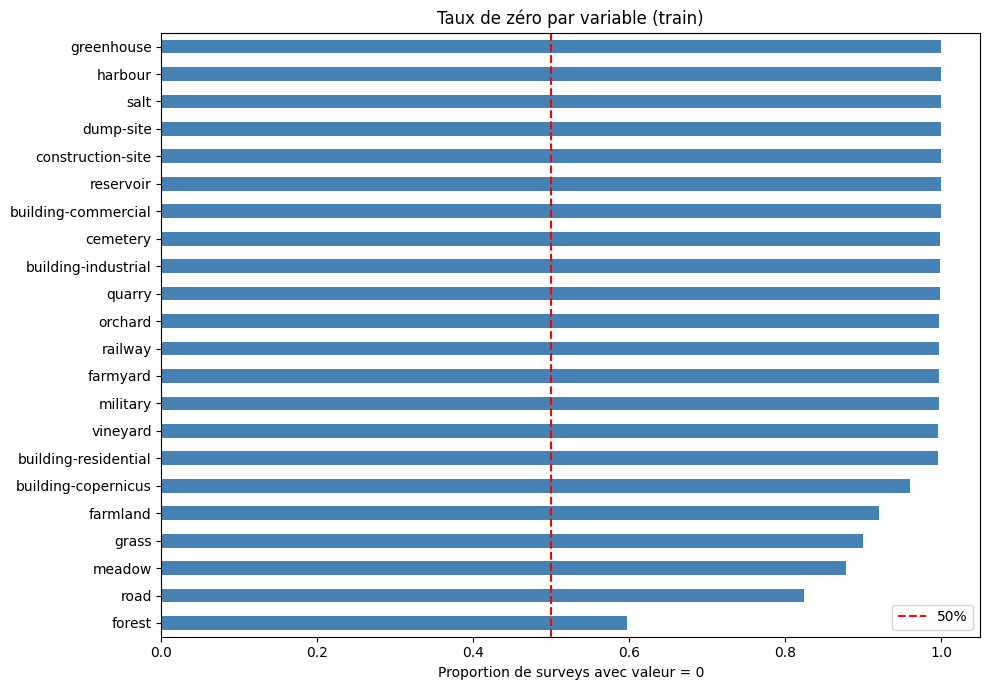

In [4]:
# La plupart des variables sont des pourcentages de couverture → beaucoup de 0
zero_rate = (train[hf_cols] == 0).mean().sort_values(ascending=True)
zero_rate.index = [c.replace('HumanFootprint-', '') for c in zero_rate.index]

fig, ax = plt.subplots(figsize=(10, 7))
zero_rate.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Taux de zéro par variable (train)')
ax.set_xlabel('Proportion de surveys avec valeur = 0')
ax.axvline(0.5, color='red', linestyle='--', label='50%')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Distribution des variables (non-nulles)

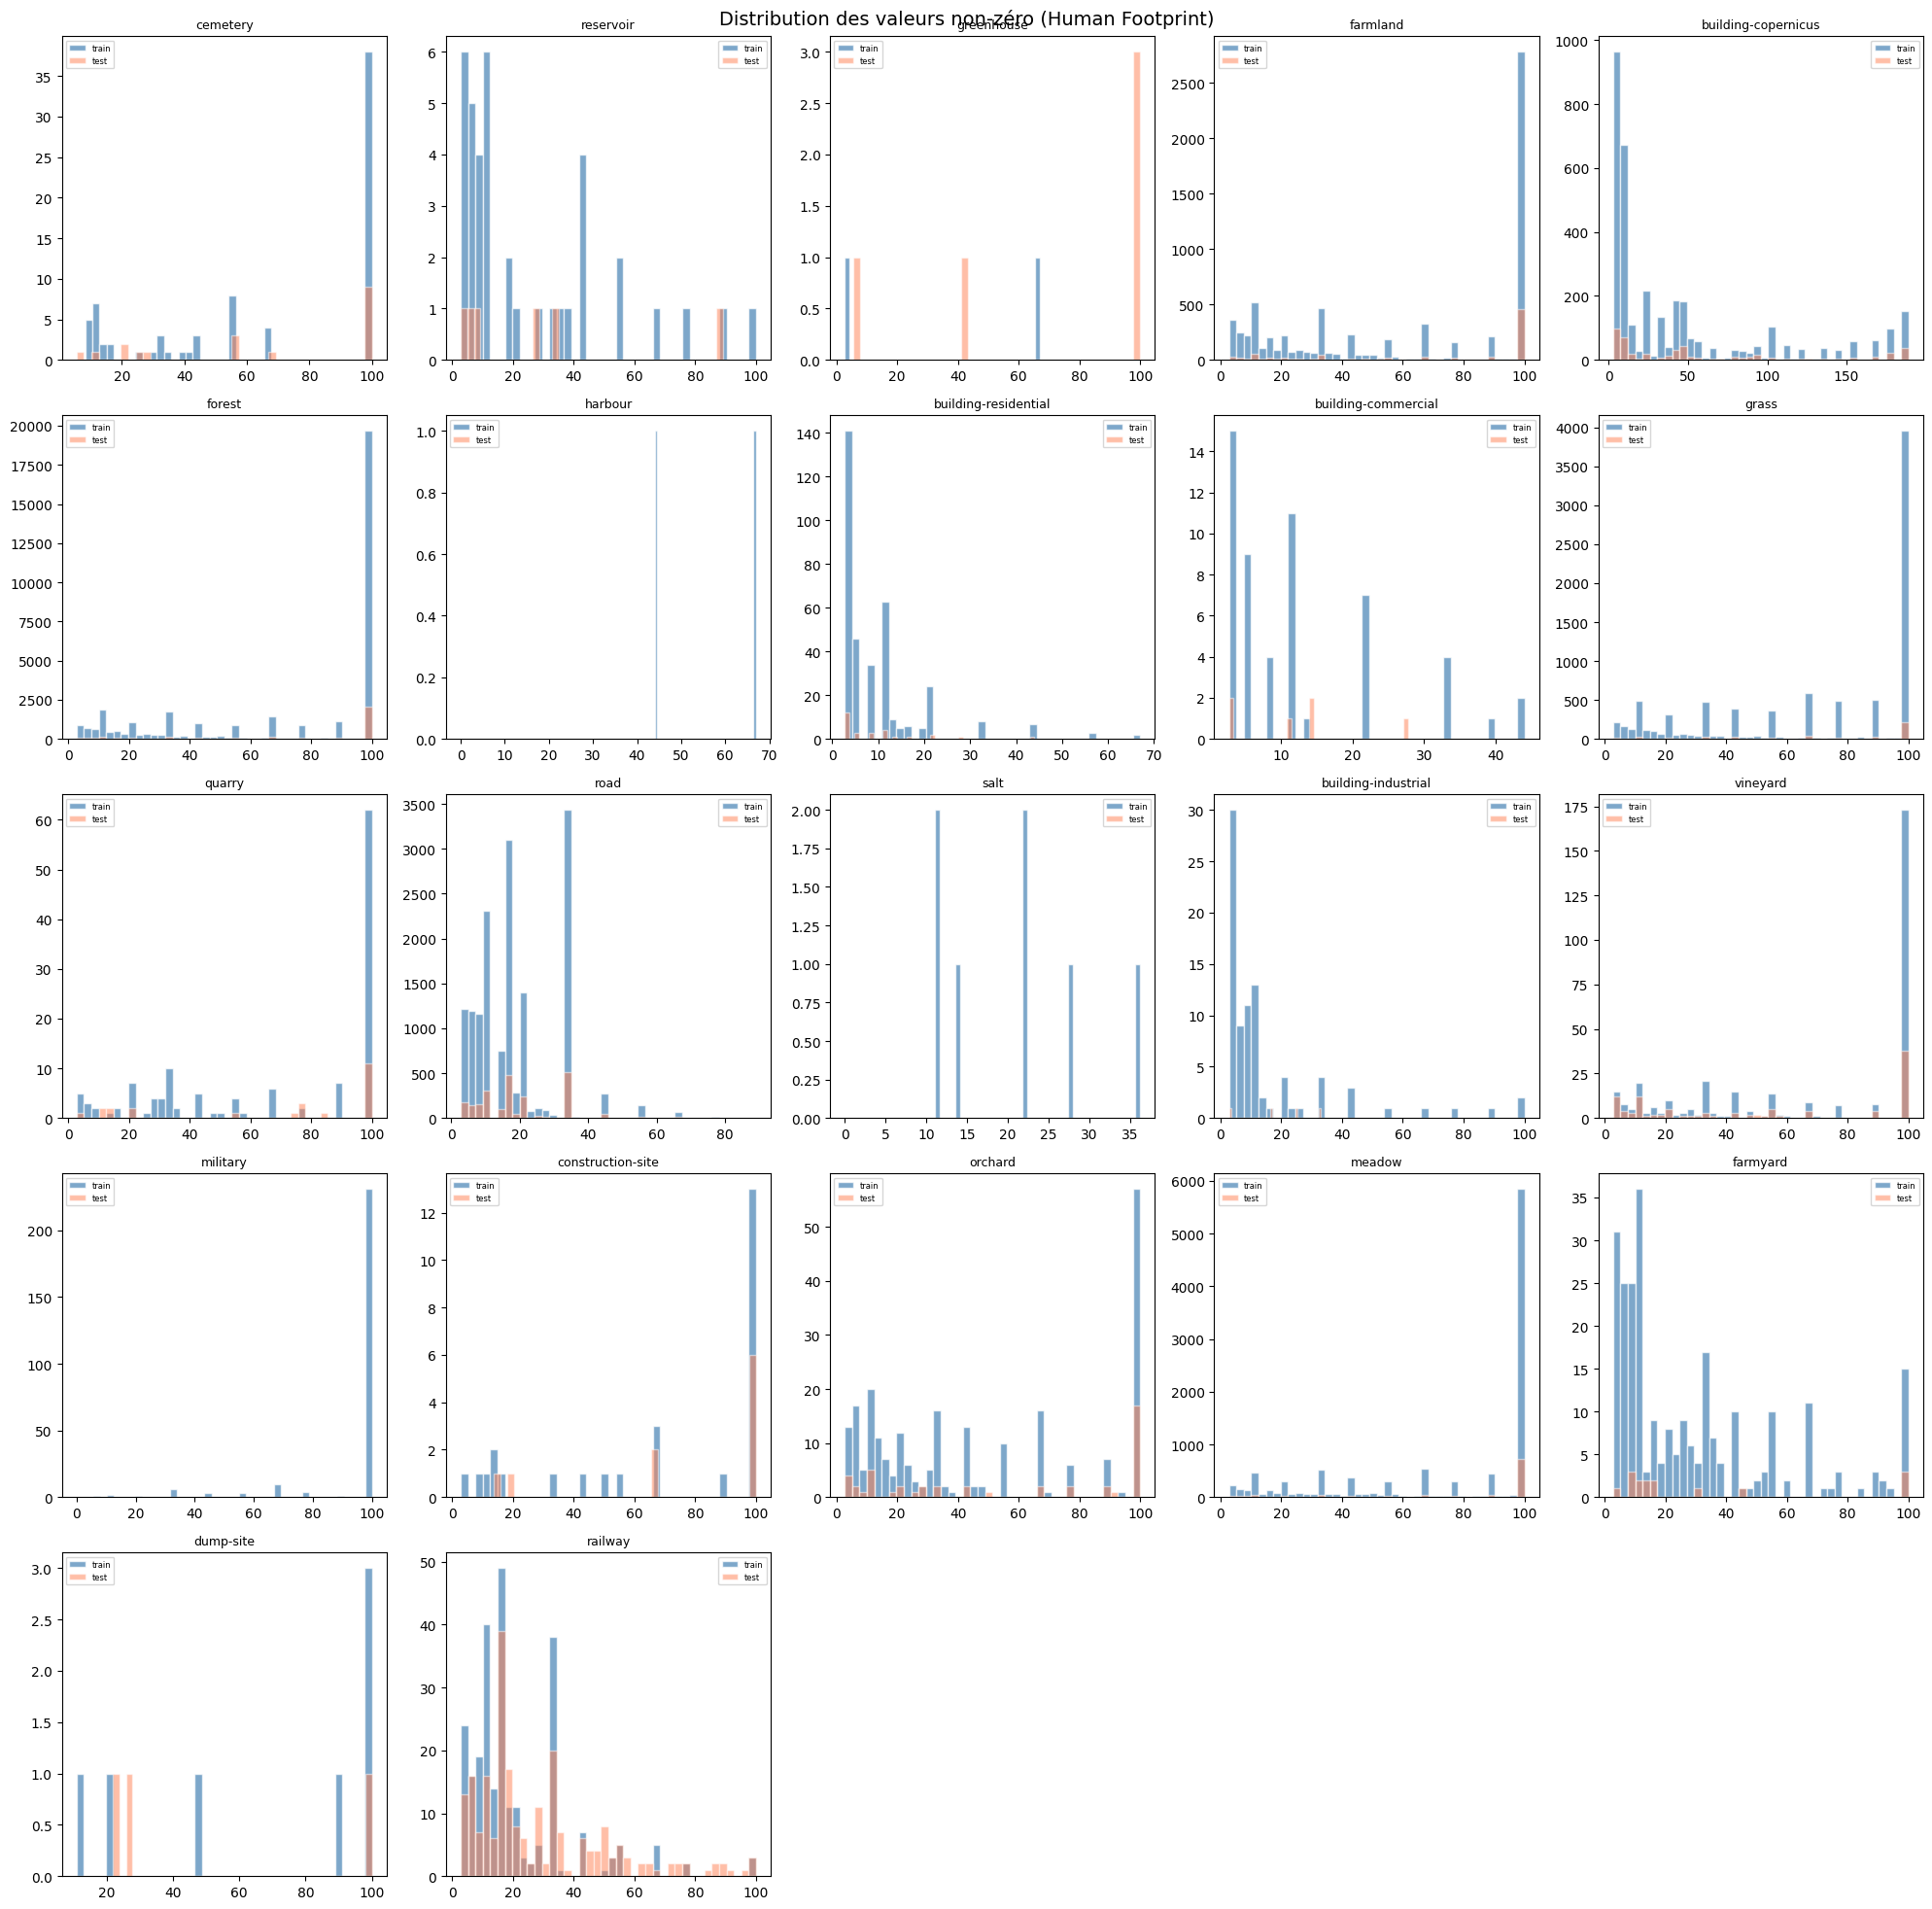

In [5]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for i, (col, name) in enumerate(zip(hf_cols, short_names)):
    nonzero_train = train[col][train[col] > 0].dropna()
    nonzero_test  = test[col][test[col] > 0].dropna()
    axes[i].hist(nonzero_train, bins=40, color='steelblue', alpha=0.7, label='train', edgecolor='white')
    axes[i].hist(nonzero_test, bins=40, color='coral', alpha=0.5, label='test', edgecolor='white')
    axes[i].set_title(name, fontsize=9)
    axes[i].legend(fontsize=6)

for j in range(len(hf_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution des valeurs non-zéro (Human Footprint)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Matrice de corrélation (Spearman)

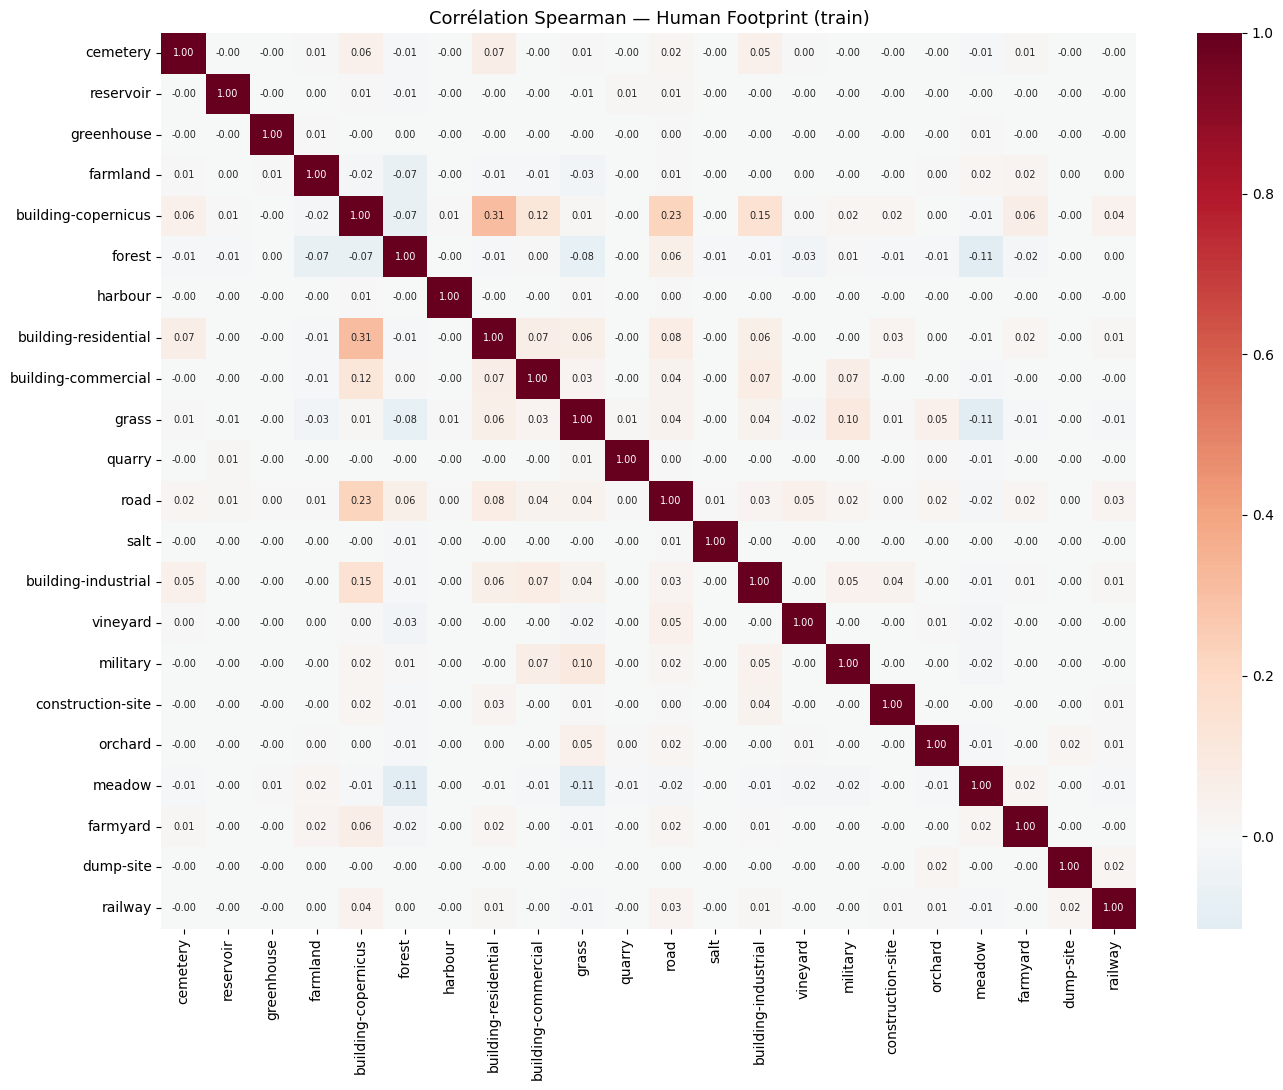

In [6]:
corr = train[hf_cols].corr(method='spearman')
corr.columns = short_names
corr.index = short_names

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Corrélation Spearman — Human Footprint (train)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Indice composite d'anthropisation

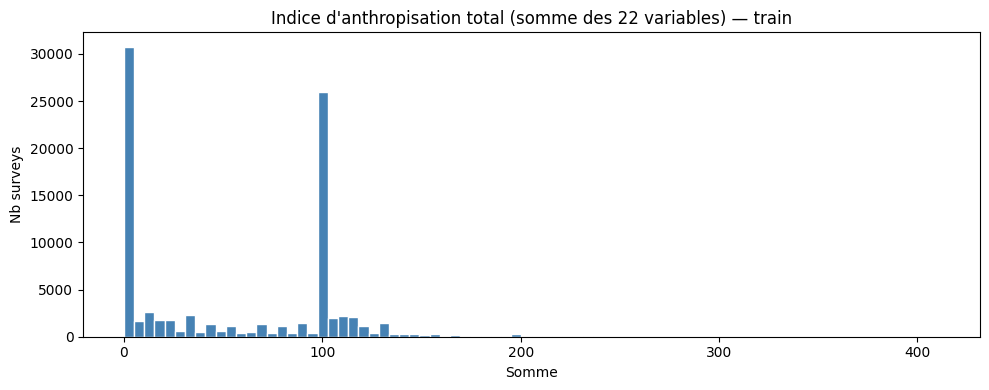

Surveys avec footprint total = 0 : 29681 (33.4%)


In [7]:
# Somme de toutes les variables comme proxy d'anthropisation globale
train['total_footprint'] = train[hf_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train['total_footprint'], bins=80, color='steelblue', edgecolor='white')
ax.set_title('Indice d\'anthropisation total (somme des 22 variables) — train')
ax.set_xlabel('Somme')
ax.set_ylabel('Nb surveys')
plt.tight_layout()
plt.show()

print(f'Surveys avec footprint total = 0 : {(train["total_footprint"] == 0).sum()} '
      f'({100*(train["total_footprint"] == 0).mean():.1f}%)')